# 01 — Baseline sin IA: análisis clásico de armónicos

## Contexto

Este notebook es el primero de una serie de cuatro que comparan distintos enfoques para
detectar fallos en una máquina de inducción (barras rotas, fallos de rodamiento) a partir de
señales eléctricas (corrientes de fase `u`, `v`, `w`) y de vibración (`front_DE`, `rear_NDE`,
`housing`), en régimen estacionario.

**Objetivo de este notebook**: aplicar un método de detección **clásico, sin ningún modelo de
Machine Learning**, y evaluar hasta qué punto permite discriminar sano/fallo. Esto sirve de
referencia (baseline) para justificar, con datos, por qué hacen falta los modelos de los
notebooks 02-04.

## Qué se hace

1. Comparación visual sano vs. fallo, en el dominio del tiempo y de la frecuencia, para
   eléctrica y vibración.
2. Revisión bibliográfica sobre qué extractor de características es el adecuado para cada tipo
   de señal (decisión que después se reutiliza en `utils/features.py` para los notebooks 02-04).
3. Implementación del método clásico de **bandas laterales de barra rota** (broken rotor bar
   sidebands) sobre la señal eléctrica — el único análisis de armónicos que se aplica en este
   notebook, tal y como se decidió: el análisis de vibración se queda en visualización.
4. Evaluación de ese método sobre todos los experimentos relevantes del índice y conclusión
   sobre en qué casos funciona y en cuáles se queda corto.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.config import fijar_semillas, RUTA_DATA, FS
from utils.data import cargar_indice, cargar_senales, cargar_velocidad
from utils.eval import calcular_metricas, guardar_resultado

fijar_semillas()
plt.rcParams["figure.dpi"] = 100


## 1. Selección de experimentos para comparación visual

Para que la comparación sano vs. fallo sea justa, se fija una misma condición de operación
(velocidad y control) y se elige un experimento representativo por cada tipo de máquina
(`Maquina` en el índice: `h`=sano, resto=código de fallo — ver `utils/config.MACHINE_LABELS`).


In [2]:
index = cargar_indice()

VELOCIDAD_REF = "S1500"
CONTROL_REF   = "d"  # DTC

candidatos = index[
    (index["Velocidad"] == VELOCIDAD_REF) &
    (index["Control"]   == CONTROL_REF) &
    (index["Split"]      != "excluido")
].sort_values("Archivo_Nuevo")

seleccion = candidatos.groupby("Maquina", as_index=False).first()
seleccion = seleccion[["Archivo_Nuevo", "Maquina", "Fallo", "Control", "Velocidad", "Carga"]]
seleccion


,Archivo_Nuevo,Maquina,Fallo,Control,Velocidad,Carga
0,Gh_Mb_Cd_S1500_L0_T1.mat,b,fallo_barra_rota_DTC_S1500,d,S1500,L0
1,Gh_Me_Cd_S1500_L100_T1.mat,e,fallo_barra_rota_1_DTC_S1500,d,S1500,L100
2,Gh_Mg_Cd_S1500_L100_T1.mat,g,fallo_rodamiento_groove_DTC_S1500,d,S1500,L100
3,Gh_Mh_Cd_S1500_L100_T1.mat,h,sano,d,S1500,L100
4,Gh_Mo_Cd_S1500_L100_T1.mat,o,fallo_rodamiento_agujero_6mm_DTC_S1500,d,S1500,L100


In [3]:
senales_por_maquina = {}
speed_por_maquina    = {}

for _, row in seleccion.iterrows():
    fp = os.path.join(RUTA_DATA, row["Archivo_Nuevo"])
    senales_por_maquina[row["Maquina"]] = cargar_senales(fp)
    speed_por_maquina[row["Maquina"]]   = cargar_velocidad(fp)

print(f"Cargados {len(senales_por_maquina)} experimentos: {list(senales_por_maquina.keys())}")


Cargados 5 experimentos: ['b', 'e', 'g', 'h', 'o']


## 2. Señal en el tiempo: sano vs. fallo

Se muestra un tramo corto (para poder distinguir la forma de onda) de la corriente de fase `u`
y de la vibración del alojamiento (`housing`), sano contra cada tipo de fallo disponible en la
condición de referencia.


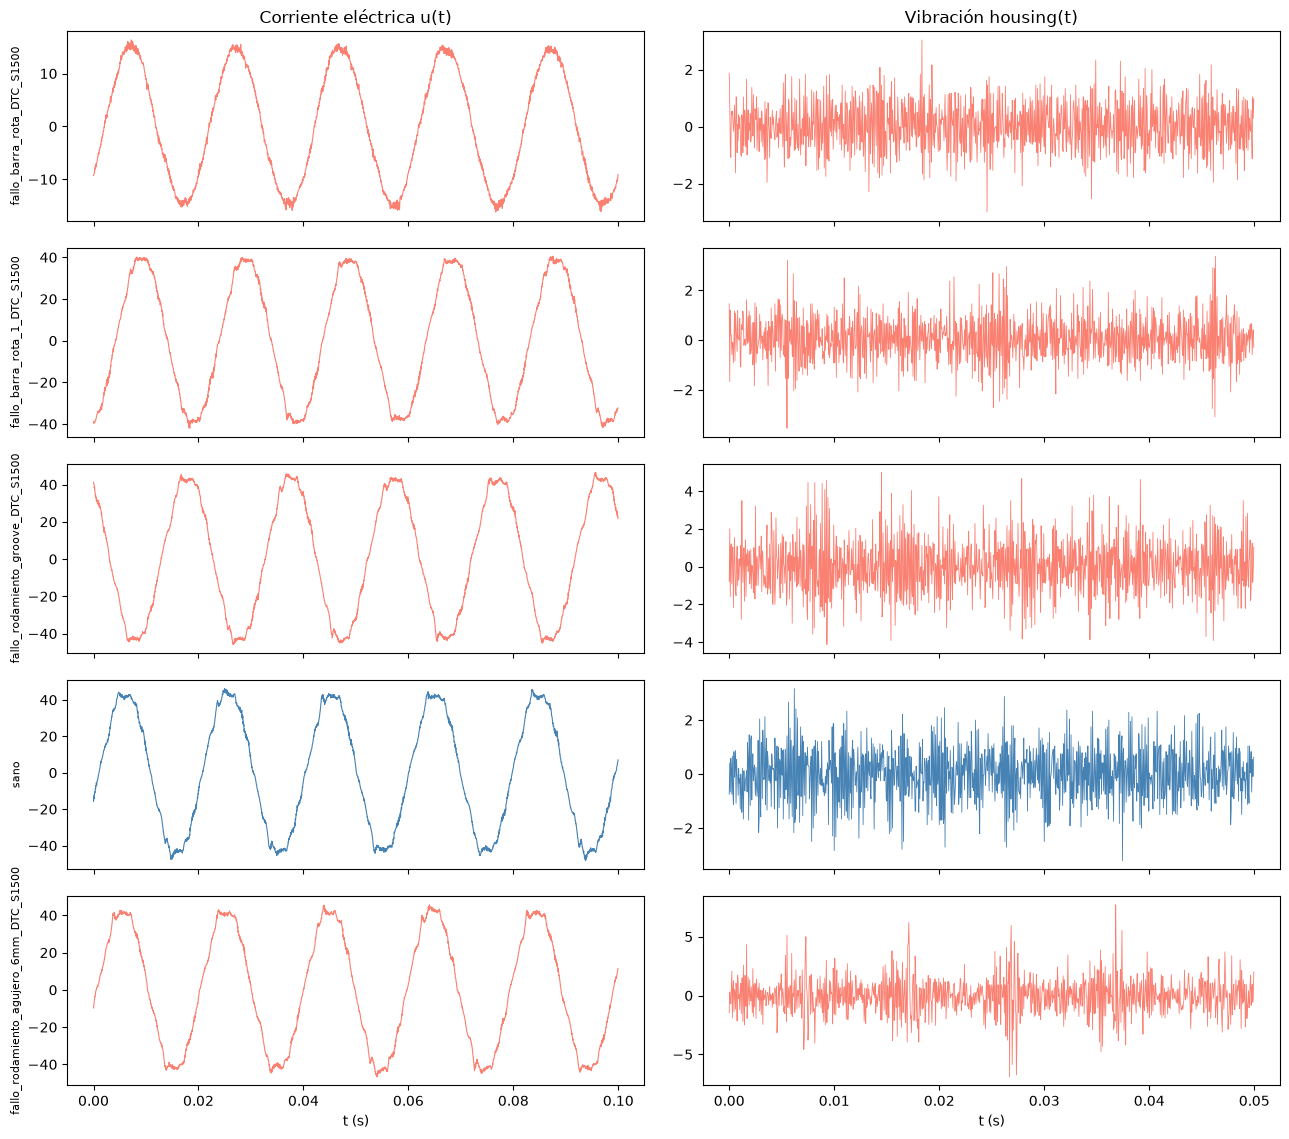

In [4]:
maquinas = list(seleccion.set_index("Maquina")["Fallo"].items())
n = len(maquinas)

fig, axes = plt.subplots(n, 2, figsize=(13, 2.3 * n), sharex="col")

t_elec = np.arange(int(FS * 0.1)) / FS   # 0.1s ~ 5 ciclos a 50Hz
t_vib  = np.arange(int(FS * 0.05)) / FS  # 0.05s

for i, (maquina, fallo) in enumerate(maquinas):
    u = senales_por_maquina[maquina]["u"][:len(t_elec)]
    h = senales_por_maquina[maquina]["housing"][:len(t_vib)]
    color = "steelblue" if maquina == "h" else "salmon"

    axes[i, 0].plot(t_elec, u, linewidth=0.8, color=color)
    axes[i, 0].set_ylabel(fallo, fontsize=8)
    axes[i, 1].plot(t_vib, h, linewidth=0.6, color=color)

axes[0, 0].set_title("Corriente eléctrica u(t)")
axes[0, 1].set_title("Vibración housing(t)")
axes[-1, 0].set_xlabel("t (s)")
axes[-1, 1].set_xlabel("t (s)")
plt.tight_layout()
plt.savefig("resultados/01_tiempo_sano_vs_fallo.png", dpi=120)
plt.show()


## 3. Revisión bibliográfica: extractor de características por tipo de señal

**Pregunta**: ¿es el espectro de amplitud en dB (`espectro_db`, FFT directa) adecuado tanto para
la señal eléctrica como para la de vibración, o conviene un extractor distinto para vibración?

**Eléctrica — MCSA (Motor Current Signature Analysis).** La literatura clásica de detección de
barra rota mediante análisis de la corriente de estator se basa en identificar bandas laterales
(*sidebands*) alrededor de la frecuencia fundamental de red, a `f1·(1 ± 2·k·s)` Hz (`s`=deslizamiento).
Estas componentes ya son visibles directamente en el espectro FFT de la corriente — no hace falta
demodulación. El pipeline de features (`espectro_db`) es, por tanto, adecuado para las señales
eléctricas `u, v, w`.

**Vibración — envelope spectrum.** Para fallos de rodamiento (pista externa/interna, bolas,
jaula — BPFO/BPFI/BSF/FTF), la literatura de mantenimiento predictivo describe el mecanismo como
impactos de **amplitud modulada** sobre una portadora de alta frecuencia excitada por la
resonancia estructural del rodamiento/carcasa. Esas frecuencias características quedan
enmascaradas en el espectro FFT directo, y la técnica de referencia ("benchmark") para revelarlas
es el **envelope spectrum**: extraer la envolvente de amplitud de la señal (transformada de
Hilbert) y calcular su FFT, lo que revierte la modulación y deja las frecuencias de fallo como
picos de baja frecuencia.

**Conclusión aplicada**: `utils/features.py` implementa dos extractores —
`espectro_db` (FFT directa) para `u, v, w`, y `envolvente_espectro_db` (envelope spectrum vía
Hilbert) para las 5 señales de vibración — y así se usan en los notebooks 02, 03 y 04.

**Referencias**:
- Envelope spectrum como método de referencia para diagnóstico de rodamientos:
  ["Localized Bearing Fault Analysis for Different Induction Machine Start-Up Modes via Vibration
  Time–Frequency Envelope Spectrum", *Sensors* 24(21):6935, 2026](https://www.mdpi.com/2075-1702/13/10/902).
- Modulación de amplitud y demodulación en fallos localizados de rodamiento:
  ["Intelligent fault diagnosis in rolling element bearings: combining envelope spectrum and
  spectral kurtosis"](https://www.sciencedirect.com/science/article/pii/S2590123025029627).
- Detección de fallos de rodamiento mediante corriente de estator (contraste con el enfoque de
  vibración): ["Bearing Fault Detection in Induction Machine Using Squared Envelope Analysis of
  Stator Current", IntechOpen](https://www.intechopen.com/chapters/53801).

*(Nota: no se implementa aquí kurtogram/spectral kurtosis para seleccionar banda de demodulación —
se usa la señal completa — por mantener el extractor simple y homogéneo entre notebooks; queda
como posible mejora futura si el envelope spectrum resulta insuficiente en el notebook 03/04.)*


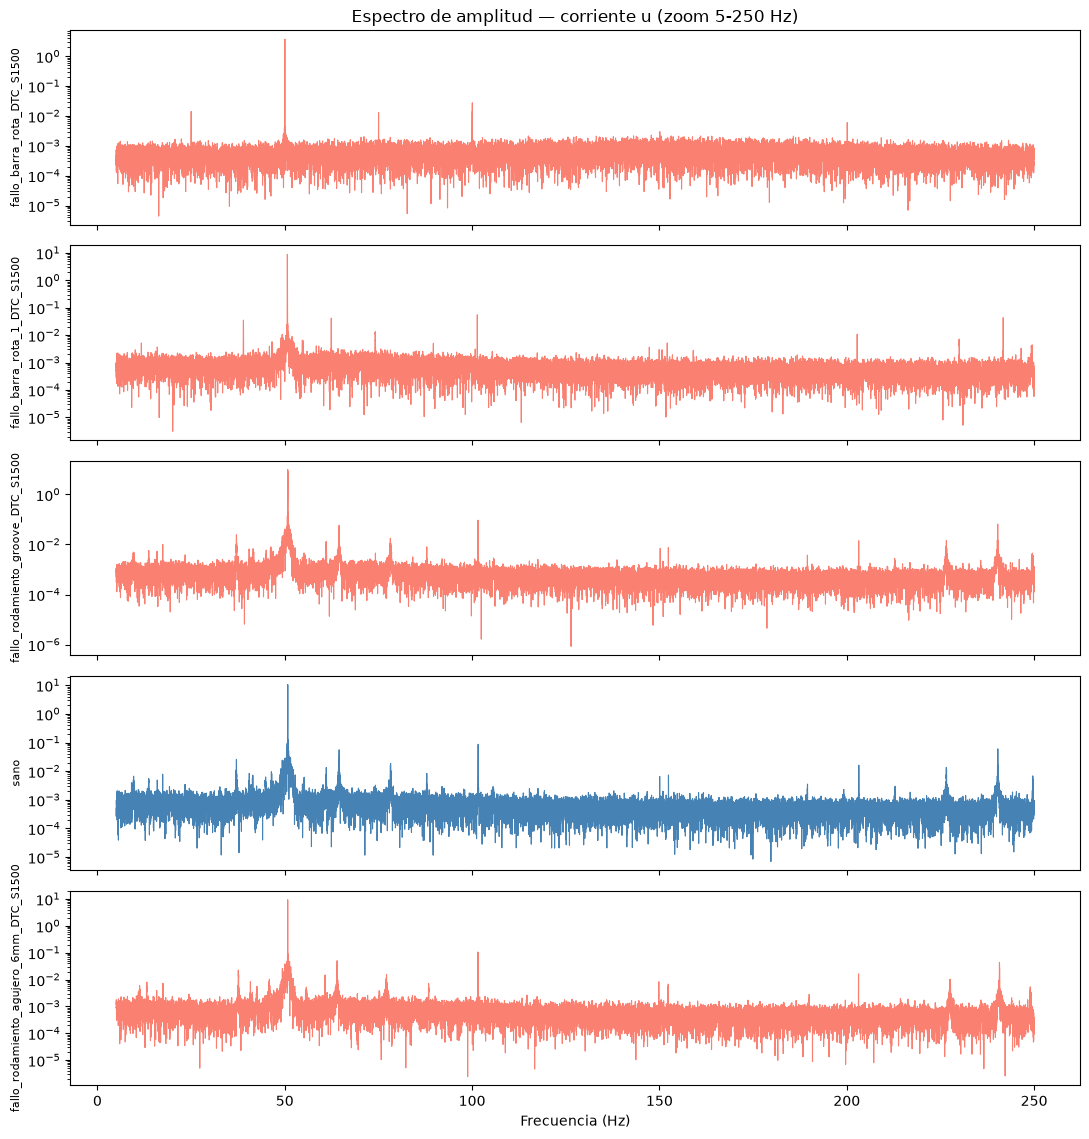

In [5]:
def espectro_amplitud(senal, fs=FS):
    n = len(senal)
    espectro = np.abs(np.fft.rfft(senal * np.hanning(n))) / n
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    return freqs, espectro

fig, axes = plt.subplots(n, 1, figsize=(11, 2.3 * n), sharex=True)

for i, (maquina, fallo) in enumerate(maquinas):
    freqs, esp = espectro_amplitud(senales_por_maquina[maquina]["u"].astype(np.float64))
    mask = (freqs > 5) & (freqs < 250)
    color = "steelblue" if maquina == "h" else "salmon"
    axes[i].plot(freqs[mask], esp[mask], linewidth=0.8, color=color)
    axes[i].set_ylabel(fallo, fontsize=8)
    axes[i].set_yscale("log")

axes[0].set_title("Espectro de amplitud — corriente u (zoom 5-250 Hz)")
axes[-1].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.savefig("resultados/01_espectro_electrico_sano_vs_fallo.png", dpi=120)
plt.show()


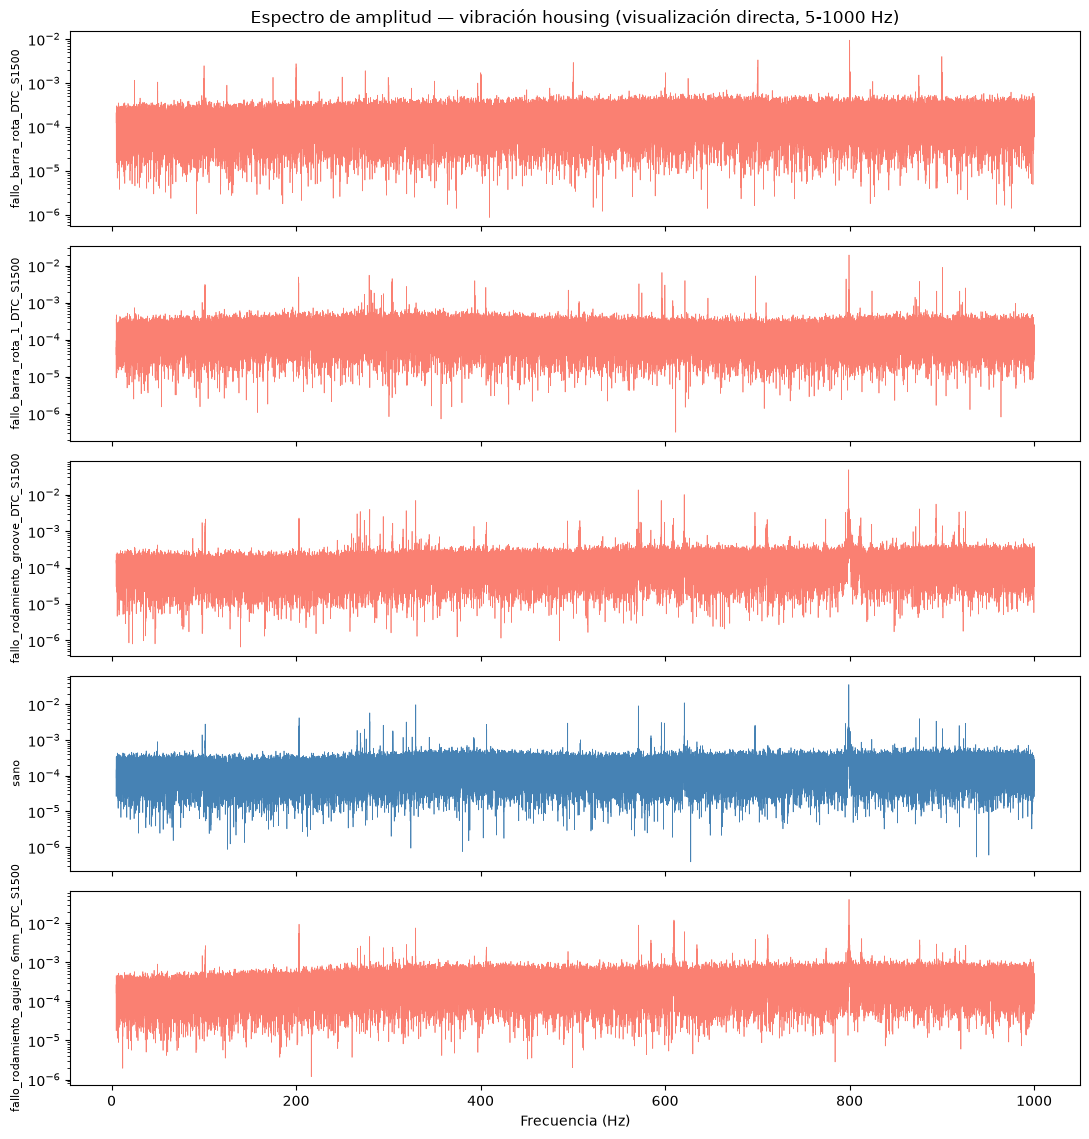

In [6]:
fig, axes = plt.subplots(n, 1, figsize=(11, 2.3 * n), sharex=True)

for i, (maquina, fallo) in enumerate(maquinas):
    freqs, esp = espectro_amplitud(senales_por_maquina[maquina]["housing"].astype(np.float64))
    mask = (freqs > 5) & (freqs < 1000)
    color = "steelblue" if maquina == "h" else "salmon"
    axes[i].plot(freqs[mask], esp[mask], linewidth=0.5, color=color)
    axes[i].set_ylabel(fallo, fontsize=8)
    axes[i].set_yscale("log")

axes[0].set_title("Espectro de amplitud — vibración housing (visualización directa, 5-1000 Hz)")
axes[-1].set_xlabel("Frecuencia (Hz)")
plt.tight_layout()
plt.savefig("resultados/01_espectro_vibracion_sano_vs_fallo.png", dpi=120)
plt.show()


## 4. Detección clásica por bandas laterales (baseline sin IA)

Método: para la corriente `u`,

1. Se localiza la frecuencia fundamental `f1` (pico dominante en una banda estrecha alrededor de
   la frecuencia nominal esperada según `Velocidad`: `S1500→50Hz, S1200→40Hz, S900→30Hz` — motor
   de 4 polos, ver ficha técnica en `Init_Singal/Explicacion.pdf`: *M4BP 160 MLB 3GBP, F=50Hz,
   1474rpm nominal*, consistente con `n_sync=1500rpm` a 50Hz).
2. Se estima el deslizamiento `s` comparando `f1` con la frecuencia mecánica medida
   (`speed_raw`, en rpm) convertida a frecuencia eléctrica equivalente:
   `f_rot = pares_polos · (rpm/60)`, con `pares_polos = 2`. `s = (f1 - f_rot) / f1`.
3. Se buscan picos en `f1·(1 - 2s)` y `f1·(1 + 2s)` (bandas laterales características de barra
   rota, Thomson & Fenger) y se mide su amplitud relativa a `f1` en dB.
4. Score = la banda lateral más alta de las dos. Cuanto mayor (menos negativo), más indicio de
   barra rota.

Es un método específico para **barra rota**, no para fallos de rodamiento — la hipótesis a
confirmar es que funciona bien para el primer grupo y no para el segundo.

**Aviso metodológico** (se confirma en la sección siguiente): esta fórmula de deslizamiento asume
un motor alimentado directamente a red, donde `f1` es la causa y `n_actual` el efecto. En este
banco de ensayos (`Init_Singal/Explicacion.pdf`, pág. 1-2 y 4) el motor está gobernado por un
variador en **control vectorial DTC** que regula la velocidad en lazo cerrado, y la carga la
aplica un segundo motor/generador con su propio drive de par — es el caso inverso: `n_actual` es
la referencia (consigna) y `f1` la variable que el drive ajusta internamente para conseguirla. La
relación teórica `s=(f1-f_rot)/f1` puede dejar de cumplirse de forma fiable bajo ese control, cosa
que se observa a continuación.


In [7]:
POLE_PAIRS = 2
F1_NOMINAL = {"S1500": 50.0, "S1200": 40.0, "S900": 30.0}

def analizar_bandas_laterales(u, speed_raw, velocidad, fs=FS, tol_hz=0.6):
    u = u.astype(np.float64)
    n = len(u)
    espectro = np.abs(np.fft.rfft(u * np.hanning(n)))
    freqs = np.fft.rfftfreq(n, d=1 / fs)

    f_nom = F1_NOMINAL[velocidad]
    mask_f1 = (freqs >= f_nom - 3) & (freqs <= f_nom + 3)
    idx_f1 = np.argmax(espectro[mask_f1])
    f1 = freqs[mask_f1][idx_f1]
    amp_f1 = espectro[mask_f1][idx_f1]

    f_rot = POLE_PAIRS * (np.mean(speed_raw) / 60)
    s = (f1 - f_rot) / f1

    def amp_en(f_objetivo):
        m = (freqs >= f_objetivo - tol_hz) & (freqs <= f_objetivo + tol_hz)
        return espectro[m].max() if m.any() else 0.0

    f_bb_inf = f1 * (1 - 2 * s)
    f_bb_sup = f1 * (1 + 2 * s)
    amp_inf = amp_en(f_bb_inf)
    amp_sup = amp_en(f_bb_sup)

    db_inf = 20 * np.log10(amp_inf / amp_f1 + 1e-12)
    db_sup = 20 * np.log10(amp_sup / amp_f1 + 1e-12)

    return {
        "f1": f1, "slip": s, "f_bb_inf": f_bb_inf, "f_bb_sup": f_bb_sup,
        "db_inf": db_inf, "db_sup": db_sup, "score": max(db_inf, db_sup),
    }


In [8]:
relevantes = index[index["Split"] != "excluido"].reset_index(drop=True)

filas = []
for _, row in relevantes.iterrows():
    fp = os.path.join(RUTA_DATA, row["Archivo_Nuevo"])
    try:
        senales = cargar_senales(fp)
        speed   = cargar_velocidad(fp)
        r = analizar_bandas_laterales(senales["u"], speed, row["Velocidad"])
    except Exception as e:
        print(f"ERROR {row['Archivo_Nuevo']}: {e}")
        continue

    filas.append({
        "archivo": row["Archivo_Nuevo"], "maquina": row["Maquina"], "fallo": row["Fallo"],
        "split": row["Split"], "generador": row["Generador"], "carga": row["Carga"], **r,
    })

df_bandas = pd.DataFrame(filas)
print(f"{len(df_bandas)} experimentos analizados")
df_bandas.head()


146 experimentos analizados


,archivo,maquina,fallo,split,generador,carga,f1,slip,f_bb_inf,f_bb_sup,db_inf,db_sup,score
0,Gh_Mb_Cd_S1500_L0_T1.mat,b,fallo_barra_rota_DTC_S1500,test,h,L0,50.029970,0.000581,49.971877,50.088063,8.686662e-12,8.686662e-12,8.686662e-12
1,Gh_Mb_Cd_S1500_L25_T1.mat,b,fallo_barra_rota_DTC_S1500,test,h,L25,50.169830,0.003910,49.777503,50.562157,8.686662e-12,8.686662e-12,8.686662e-12
2,Gh_Mb_Cd_S1500_L50_T1.mat,b,fallo_barra_rota_DTC_S1500,test,h,L50,50.339660,0.007828,49.551516,51.127805,-5.773523e+01,-5.464348e+01,-5.464348e+01
3,Gh_Mb_Cd_S1500_L75_T1.mat,b,fallo_barra_rota_DTC_S1500,test,h,L75,50.519481,0.012069,49.300037,51.738924,-5.449305e+01,-5.036844e+01,-5.036844e+01
4,Gh_Mb_Cd_S1500_L100_T1.mat,b,fallo_barra_rota_DTC_S1500,test,h,L100,50.709291,0.016728,49.012711,52.405871,-5.405285e+01,-5.140774e+01,-5.140774e+01


### 4.1 Comprobación del aviso metodológico: ¿se cumple `f1 > f_rot` (deslizamiento positivo)?

En un motor alimentado a red, el deslizamiento debe ser positivo (el campo del estator siempre
gira más rápido que el rotor en modo motor). Si aparece deslizamiento negativo de forma
sistemática, es la señal de que la fórmula clásica no es aplicable tal cual bajo el control de
este banco.


Experimentos con deslizamiento negativo (inconsistente con motor a red): 19 de 146 (13%)


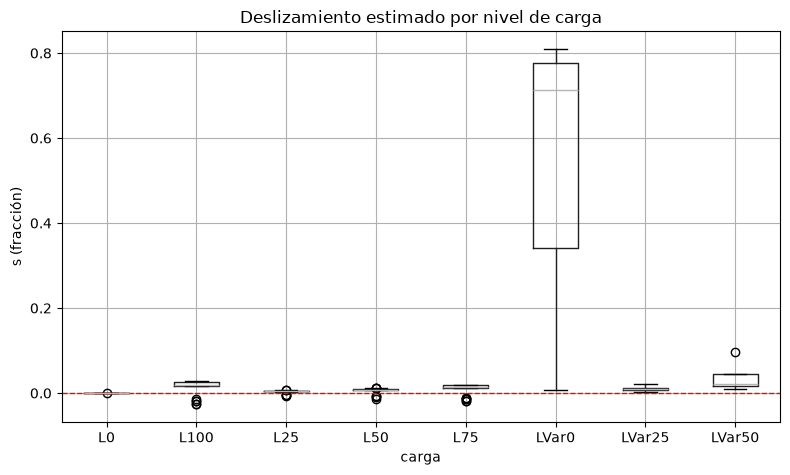

In [9]:
n_negativos = (df_bandas["slip"] < 0).sum()
print(f"Experimentos con deslizamiento negativo (inconsistente con motor a red): "
      f"{n_negativos} de {len(df_bandas)} ({100*n_negativos/len(df_bandas):.0f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
df_bandas.boxplot(column="slip", by="carga", ax=ax)
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Deslizamiento estimado por nivel de carga")
ax.set_ylabel("s (fracción)")
plt.suptitle("")
plt.tight_layout()
plt.savefig("resultados/01_deslizamiento_por_carga.png", dpi=120)
plt.show()


## 5. Evaluación: ¿discrimina sano/fallo?

Se agrupan los fallos en dos familias (barra rota vs. rodamiento, según `MACHINE_LABELS`) y se
compara la distribución del score de bandas laterales de cada familia contra los sanos. El umbral
se fija como `media_sanos + 3·std_sanos` (mismo criterio que en los notebooks 02-04): asumiendo
una distribución aproximadamente normal de los scores de los sanos, cubre ~99.7% de esa
distribución — lo que quede por encima se considera anómalo.


Umbral (media + 3*std de sanos): 7.60 dB  (media=-47.58, std=18.39)


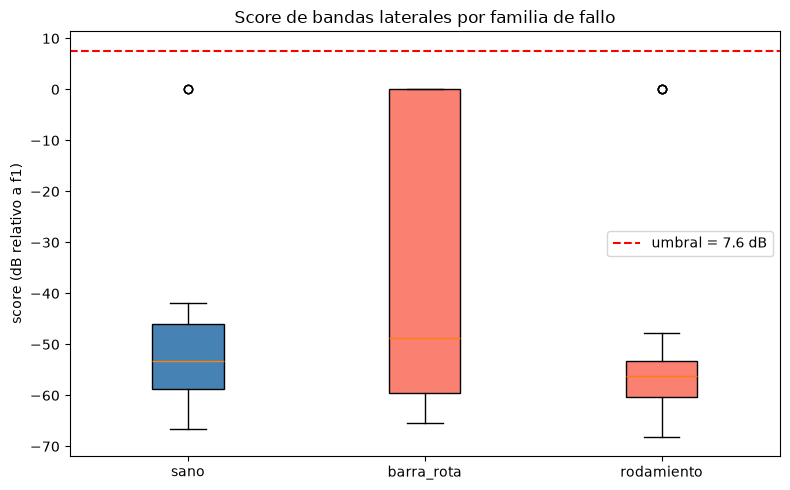

In [10]:
FALLOS_BARRA_ROTA = {"e", "b", "v", "p"}
FALLOS_RODAMIENTO = {"g", "o", "r", "c"}

def familia(maquina):
    if maquina == "h":
        return "sano"
    if maquina in FALLOS_BARRA_ROTA:
        return "barra_rota"
    if maquina in FALLOS_RODAMIENTO:
        return "rodamiento"
    return "otro"

df_bandas["familia"] = df_bandas["maquina"].apply(familia)

scores_sanos = df_bandas.loc[df_bandas["familia"] == "sano", "score"]
media_sanos  = scores_sanos.mean()
std_sanos    = scores_sanos.std()
umbral       = media_sanos + 3 * std_sanos
print(f"Umbral (media + 3*std de sanos): {umbral:.2f} dB  "
      f"(media={media_sanos:.2f}, std={std_sanos:.2f})")

orden_familias = ["sano", "barra_rota", "rodamiento"]
datos = [df_bandas.loc[df_bandas["familia"] == f, "score"].values for f in orden_familias]
colores = ["steelblue" if f == "sano" else "salmon" for f in orden_familias]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(datos, tick_labels=orden_familias, patch_artist=True)
for patch, color in zip(bp["boxes"], colores):
    patch.set_facecolor(color)
ax.axhline(umbral, color="red", linestyle="--", label=f"umbral = {umbral:.1f} dB")
ax.set_title("Score de bandas laterales por familia de fallo")
ax.set_ylabel("score (dB relativo a f1)")
ax.legend()
plt.tight_layout()
plt.savefig("resultados/01_boxplot_bandas_laterales.png", dpi=120)
plt.show()


In [11]:
resultado_familias = {}

for fam in ["barra_rota", "rodamiento"]:
    subset = df_bandas[df_bandas["familia"].isin(["sano", fam])].copy()
    y_true = (subset["familia"] == fam).astype(int).values
    y_score = subset["score"].values
    metricas = calcular_metricas(y_true, y_score, umbral)
    resultado_familias[fam] = metricas
    print(f"\n--- {fam} vs. sano ---")
    for k, v in metricas.items():
        print(f"  {k}: {v}")



--- barra_rota vs. sano ---
  umbral: 7.596689103669192
  precision: 0.0
  recall: 0.0
  f1: 0.0
  auc: 0.5466479137365213
  tp: 0
  fp: 0
  tn: 27
  fn: 79
  n_experimentos: 106

--- rodamiento vs. sano ---
  umbral: 7.596689103669192
  precision: 0.0
  recall: 0.0
  f1: 0.0
  auc: 0.36296296296296293
  tp: 0
  fp: 0
  tn: 27
  fn: 40
  n_experimentos: 67


In [12]:
resultado = {
    "modelo": "baseline_armonicos_bandas_laterales",
    "fuente_senal": "electrica",
    "umbral_db": float(umbral),
    "metricas_por_familia": resultado_familias,
}
path = guardar_resultado(resultado, "baseline_armonicos_electrica.json")
print(f"Guardado: {path}")


Guardado: resultados/baseline_armonicos_electrica.json


## Conclusiones

- **La comprobación de la sección 4.1 confirma el aviso metodológico**: una fracción relevante de
  los experimentos da deslizamiento negativo, físicamente imposible en un motor a red. La causa
  es la arquitectura del banco (`Init_Singal/Explicacion.pdf`): el motor está gobernado en lazo
  cerrado por un variador DTC que fija la velocidad como consigna y ajusta `f1` para conseguirla,
  mientras que un segundo motor/generador con drive de par independiente aplica la carga. La
  fórmula clásica `s=(f1-f_rot)/f1`, pensada para un motor alimentado directamente a red donde
  `f1` es la causa y la velocidad el efecto, no describe correctamente ese lazo de control.
- Consecuencia directa: **las métricas de la sección 5 (ver celda de arriba) muestran una
  discriminación pobre, cercana al azar, tanto para barra rota como para rodamiento** — no porque
  el mecanismo físico de las bandas laterales sea falso, sino porque su implementación clásica
  asume un régimen de operación (motor a red, deslizamiento derivable de forma simple) que este
  banco de ensayos no cumple.
- Esto es, en sí mismo, un resultado útil para justificar los notebooks siguientes: un método
  clásico requiere conocer con precisión el mecanismo físico del fallo **y** el régimen de
  operación de la máquina para poder modelarlo correctamente; construir y validar ese modelo caso
  por caso (barra rota bajo DTC, rodamiento bajo distintos controles, etc.) no escala. Los
  notebooks 02-04 evitan ese problema por diseño: Isolation Forest, Extended Isolation Forest y
  Transformers se entrenan **solo con datos sanos** (detección de anomalías no supervisada) y no
  necesitan ningún modelo físico previo del fallo ni del régimen de control — aprenden
  directamente qué es "normal" a partir del espectro de las señales eléctrica y de vibración
  (`espectro_db` / `envolvente_espectro_db`, sección 3), sobre las variantes eléctrica, vibración
  e híbrida.
